<a href="https://colab.research.google.com/github/hyokim1025/-/blob/main/%EB%AA%A8%EA%B8%B0%EC%98%88%EB%B3%B4%EC%A0%9C_%ED%85%8C%ED%85%8C%EC%8A%A4%EC%8A%A4%ED%8A%B8%ED%8A%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =========================================================
# 0. 라이브러리 불러오기
# =========================================================

import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime, date

import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


OUTPUT_DIR = Path("/content/processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
# =========================================================
# 1. GitHub raw URL 설정
# =========================================================

asos_urls = {
    2020: "https://github.com/hyokim1025/-/raw/refs/heads/main/ASOS_20%EB%85%84.csv",
    2021: "https://github.com/hyokim1025/-/raw/refs/heads/main/ASOS_21%EB%85%84.csv",
    2022: "https://github.com/hyokim1025/-/raw/refs/heads/main/ASOS_22%EB%85%84.csv",
    2023: "https://github.com/hyokim1025/-/raw/refs/heads/main/ASOS_23%EB%85%84.csv",
    2024: "https://github.com/hyokim1025/-/raw/refs/heads/main/ASOS_24%EB%85%84.csv",
    2025: "https://github.com/hyokim1025/-/raw/refs/heads/main/ASOS_25%EB%85%84.csv",
}

dms_urls = {
    2020: "https://github.com/hyokim1025/-/raw/refs/heads/main/DMS%EB%AA%A8%EA%B8%B0%ED%8F%AC%EC%A7%91%EB%9F%89_20%EB%85%84.csv",
    2021: "https://github.com/hyokim1025/-/raw/refs/heads/main/DMS%EB%AA%A8%EA%B8%B0%ED%8F%AC%EC%A7%91%EB%9F%89_21%EB%85%84.csv",
    2022: "https://github.com/hyokim1025/-/raw/refs/heads/main/DMS%EB%AA%A8%EA%B8%B0%ED%8F%AC%EC%A7%91%EB%9F%89_22%EB%85%84.csv",
    2023: "https://github.com/hyokim1025/-/raw/refs/heads/main/DMS%EB%AA%A8%EA%B8%B0%ED%8F%AC%EC%A7%91%EB%9F%89_23%EB%85%84.csv",
    2024: "https://github.com/hyokim1025/-/raw/refs/heads/main/DMS%EB%AA%A8%EA%B8%B0%ED%8F%AC%EC%A7%91%EB%9F%89_24%EB%85%84.csv",
    2025: "https://github.com/hyokim1025/-/raw/refs/heads/main/DMS%EB%AA%A8%EA%B8%B0%ED%8F%AC%EC%A7%91%EB%9F%89_25%EB%85%84.csv",
}

In [3]:
# =========================================================
# 2. 공통 함수
# =========================================================

def read_csv_auto_encoding(url, header="infer"):
    encodings = ["utf-8-sig", "utf-8", "cp949", "euc-kr"]
    last_error = None

    for enc in encodings:
        try:
            return pd.read_csv(url, encoding=enc, header=header)
        except Exception as e:
            last_error = e

    raise RuntimeError(f"CSV 파일을 읽지 못했습니다: {url}\n마지막 오류: {last_error}")


def clean_column_names(df):
    df.columns = (
        df.columns
        .astype(str)
        .str.replace("\ufeff", "", regex=False)
        .str.strip()
    )
    return df


def parse_dms_date(value):
    if pd.isna(value):
        return pd.NaT

    if isinstance(value, (pd.Timestamp, datetime, date)):
        return pd.to_datetime(value)

    num = pd.to_numeric(pd.Series([value]), errors="coerce").iloc[0]

    if pd.notna(num) and 20000 <= num <= 60000:
        return pd.to_datetime(num, unit="D", origin="1899-12-30")

    return pd.to_datetime(value, errors="coerce")


def to_numeric_clean(series):
    return pd.to_numeric(
        series.astype(str)
              .str.replace(",", "", regex=False)
              .str.strip()
              .replace({"": None, "nan": None, "NaN": None}),
        errors="coerce"
    )

In [4]:
# =========================================================
# 3. DMS 모기포집량 통합
# =========================================================

def build_dms_daily():
    dms_daily_list = []

    for year, url in dms_urls.items():
        print(f"\n{year}년 DMS 데이터 불러오는 중")

        raw = read_csv_auto_encoding(url, header=None)
        raw = raw.dropna(how="all").dropna(axis=1, how="all")

        if raw.shape[1] < 4:
            raise ValueError(f"{year}년 DMS 파일 컬럼 수가 4개보다 적습니다.")

        dms = raw.iloc[:, 0:4].copy()
        dms.columns = ["date_raw", "trap_total", "mosquito_count", "other_count"]

        dms["date"] = dms["date_raw"].apply(parse_dms_date)

        dms["trap_total"] = to_numeric_clean(dms["trap_total"])
        dms["mosquito_count"] = to_numeric_clean(dms["mosquito_count"])
        dms["other_count"] = to_numeric_clean(dms["other_count"])

        dms = dms[
            dms["date"].notna() &
            dms["trap_total"].notna()
        ].copy()

        dms["date"] = dms["date"].dt.date
        dms["year"] = pd.to_datetime(dms["date"]).dt.year
        dms["month"] = pd.to_datetime(dms["date"]).dt.month
        dms["day"] = pd.to_datetime(dms["date"]).dt.day
        dms["source_year"] = year

        dms = dms[
            [
                "date",
                "year",
                "month",
                "day",
                "source_year",
                "trap_total",
                "mosquito_count",
                "other_count",
            ]
        ]

        dms_daily_list.append(dms)

        print(f"{year}년 DMS 처리 완료:", dms.shape)

    dms_daily = pd.concat(dms_daily_list, ignore_index=True)

    path = OUTPUT_DIR / "dms_mosquito_daily_2020_2025.csv"
    dms_daily.to_csv(path, index=False, encoding="utf-8-sig")

    print("\nDMS 통합 완료:", dms_daily.shape)
    print("저장:", path)

    return dms_daily


dms_daily = build_dms_daily()
display(dms_daily.head())


2020년 DMS 데이터 불러오는 중
2020년 DMS 처리 완료: (184, 8)

2021년 DMS 데이터 불러오는 중
2021년 DMS 처리 완료: (172, 8)

2022년 DMS 데이터 불러오는 중
2022년 DMS 처리 완료: (184, 8)

2023년 DMS 데이터 불러오는 중
2023년 DMS 처리 완료: (200, 8)

2024년 DMS 데이터 불러오는 중
2024년 DMS 처리 완료: (244, 8)

2025년 DMS 데이터 불러오는 중
2025년 DMS 처리 완료: (275, 8)

DMS 통합 완료: (1259, 8)
저장: /content/processed/dms_mosquito_daily_2020_2025.csv


,date,year,month,day,source_year,trap_total,mosquito_count,other_count
0,2020-05-01,2020,5,1,2020,869.0,842.0,27.0
1,2020-05-02,2020,5,2,2020,882.0,861.0,21.0
2,2020-05-03,2020,5,3,2020,930.0,896.0,34.0
3,2020-05-04,2020,5,4,2020,1322.0,1304.0,19.0
4,2020-05-05,2020,5,5,2020,1119.0,1090.0,30.0


In [5]:
# =========================================================
# 4. ASOS 변수 설정
# =========================================================

# 기존 7개 ASOS 변수
basic_asos_cols = [
    "일시",
    "기온(°C)",
    "강수량(mm)",
    "풍속(m/s)",
    "습도(%)",
    "일사(MJ/m2)",
    "지면온도(°C)",
    "5cm 지중온도(°C)",
]

# 확장 변수: 기존 7개 + 이슬점온도, 증기압, 10/20/30cm 지중온도
extended_asos_cols = [
    "일시",
    "기온(°C)",
    "강수량(mm)",
    "풍속(m/s)",
    "습도(%)",
    "일사(MJ/m2)",
    "지면온도(°C)",
    "5cm 지중온도(°C)",
    "이슬점온도(°C)",
    "증기압(hPa)",
    "10cm 지중온도(°C)",
    "20cm 지중온도(°C)",
    "30cm 지중온도(°C)",
]

asos_rename_cols = {
    "일시": "datetime",
    "기온(°C)": "temp_c",
    "강수량(mm)": "rain_mm",
    "풍속(m/s)": "wind_mps",
    "습도(%)": "humidity_pct",
    "일사(MJ/m2)": "solar_mj_m2",
    "지면온도(°C)": "ground_temp_c",
    "5cm 지중온도(°C)": "soil_temp_5cm_c",
    "이슬점온도(°C)": "dew_point_c",
    "증기압(hPa)": "vapor_pressure_hpa",
    "10cm 지중온도(°C)": "soil_temp_10cm_c",
    "20cm 지중온도(°C)": "soil_temp_20cm_c",
    "30cm 지중온도(°C)": "soil_temp_30cm_c",
}

In [6]:
# =========================================================
# 5. ASOS 통합 및 일별 집계 함수
# =========================================================

def build_asos_daily(selected_cols, version_name):
    asos_hourly_list = []

    for year, url in asos_urls.items():
        print(f"\n{year}년 ASOS 데이터 불러오는 중 - {version_name}")

        df = read_csv_auto_encoding(url)
        df = clean_column_names(df)

        available_cols = [col for col in selected_cols if col in df.columns]
        missing_cols = [col for col in selected_cols if col not in df.columns]

        if missing_cols:
            print(f"{year}년 파일에서 없는 컬럼:", missing_cols)

        df = df[available_cols].copy()
        df = df.rename(columns={k: v for k, v in asos_rename_cols.items() if k in df.columns})

        df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")

        # 00시는 전날 마지막 시간으로 처리하기 위해 1시간 빼기
        df["date"] = (df["datetime"] - pd.Timedelta(hours=1)).dt.date

        df["year"] = pd.to_datetime(df["date"]).dt.year
        df["month"] = pd.to_datetime(df["date"]).dt.month
        df["day"] = pd.to_datetime(df["date"]).dt.day
        df["hour"] = df["datetime"].dt.hour

        for col in df.columns:
            if col not in ["datetime", "date"]:
                df[col] = pd.to_numeric(df[col], errors="coerce")

        # 강수량 결측치는 무강수로 판단하여 0 처리
        if "rain_mm" in df.columns:
            df["rain_mm"] = df["rain_mm"].fillna(0)

        # 일사량 결측치는 야간 무일사로 판단하여 0 처리
        if "solar_mj_m2" in df.columns:
            df["solar_mj_m2"] = df["solar_mj_m2"].fillna(0)

        asos_hourly_list.append(df)

        print(f"{year}년 ASOS 처리 완료:", df.shape)

    asos_hourly = pd.concat(asos_hourly_list, ignore_index=True)

    hours_per_day = (
        asos_hourly
        .groupby("date")
        .size()
        .reset_index(name="hour_count")
    )

    agg_dict = {
        "year": ("year", "first"),
        "month": ("month", "first"),

        "temp_mean": ("temp_c", "mean"),
        "temp_max": ("temp_c", "max"),
        "temp_min": ("temp_c", "min"),

        "rain_sum": ("rain_mm", "sum"),
        "rain_hours": ("rain_mm", lambda x: (x > 0).sum()),

        "wind_mean": ("wind_mps", "mean"),
        "wind_max": ("wind_mps", "max"),

        "humidity_mean": ("humidity_pct", "mean"),
        "humidity_min": ("humidity_pct", "min"),
        "humidity_max": ("humidity_pct", "max"),

        "solar_sum": ("solar_mj_m2", "sum"),

        "ground_temp_mean": ("ground_temp_c", "mean"),
        "ground_temp_max": ("ground_temp_c", "max"),
        "ground_temp_min": ("ground_temp_c", "min"),

        "soil_temp_5cm_mean": ("soil_temp_5cm_c", "mean"),

        # 확장 변수
        "dew_point_mean": ("dew_point_c", "mean"),
        "dew_point_min": ("dew_point_c", "min"),
        "dew_point_max": ("dew_point_c", "max"),

        "vapor_pressure_mean": ("vapor_pressure_hpa", "mean"),
        "vapor_pressure_max": ("vapor_pressure_hpa", "max"),

        "soil_temp_10cm_mean": ("soil_temp_10cm_c", "mean"),
        "soil_temp_20cm_mean": ("soil_temp_20cm_c", "mean"),
        "soil_temp_30cm_mean": ("soil_temp_30cm_c", "mean"),
    }

    # 실제 존재하는 컬럼만 집계
    agg_dict = {
        new_col: (old_col, func)
        for new_col, (old_col, func) in agg_dict.items()
        if old_col in asos_hourly.columns
    }

    asos_daily = (
        asos_hourly
        .groupby("date", as_index=False)
        .agg(**agg_dict)
        .merge(hours_per_day, on="date", how="left")
    )

    hourly_path = OUTPUT_DIR / f"asos_{version_name}_hourly_2020_2025.csv"
    daily_path = OUTPUT_DIR / f"asos_{version_name}_daily_2020_2025.csv"

    asos_hourly.to_csv(hourly_path, index=False, encoding="utf-8-sig")
    asos_daily.to_csv(daily_path, index=False, encoding="utf-8-sig")

    print(f"\nASOS {version_name} 시간 단위 저장:", hourly_path)
    print(f"ASOS {version_name} 일 단위 저장:", daily_path)
    print("ASOS daily:", asos_daily.shape)

    weather_cols = [
        col for col in asos_daily.columns
        if col not in ["date", "year", "month", "hour_count"]
    ]

    return asos_daily, weather_cols


asos_basic_daily, basic_weather_cols = build_asos_daily(
    basic_asos_cols,
    version_name="basic7"
)

asos_extended_daily, extended_weather_cols = build_asos_daily(
    extended_asos_cols,
    version_name="extended"
)

display(asos_basic_daily.head())
display(asos_extended_daily.head())

print("기본 ASOS weather cols:", basic_weather_cols)
print("확장 ASOS weather cols:", extended_weather_cols)


2020년 ASOS 데이터 불러오는 중 - basic7
2020년 ASOS 처리 완료: (4392, 13)

2021년 ASOS 데이터 불러오는 중 - basic7
2021년 ASOS 처리 완료: (4392, 13)

2022년 ASOS 데이터 불러오는 중 - basic7
2022년 ASOS 처리 완료: (4392, 13)

2023년 ASOS 데이터 불러오는 중 - basic7
2023년 ASOS 처리 완료: (4392, 13)

2024년 ASOS 데이터 불러오는 중 - basic7
2024년 ASOS 처리 완료: (4392, 13)

2025년 ASOS 데이터 불러오는 중 - basic7
2025년 ASOS 처리 완료: (4392, 13)

ASOS basic7 시간 단위 저장: /content/processed/asos_basic7_hourly_2020_2025.csv
ASOS basic7 일 단위 저장: /content/processed/asos_basic7_daily_2020_2025.csv
ASOS daily: (1098, 19)

2020년 ASOS 데이터 불러오는 중 - extended
2020년 ASOS 처리 완료: (4392, 18)

2021년 ASOS 데이터 불러오는 중 - extended
2021년 ASOS 처리 완료: (4392, 18)

2022년 ASOS 데이터 불러오는 중 - extended
2022년 ASOS 처리 완료: (4392, 18)

2023년 ASOS 데이터 불러오는 중 - extended
2023년 ASOS 처리 완료: (4392, 18)

2024년 ASOS 데이터 불러오는 중 - extended
2024년 ASOS 처리 완료: (4392, 18)

2025년 ASOS 데이터 불러오는 중 - extended
2025년 ASOS 처리 완료: (4392, 18)

ASOS extended 시간 단위 저장: /content/processed/asos_extended_hourly_2020_2025.csv
ASOS ex

,date,year,month,temp_mean,temp_max,temp_min,rain_sum,rain_hours,wind_mean,wind_max,humidity_mean,humidity_min,humidity_max,solar_sum,ground_temp_mean,ground_temp_max,ground_temp_min,soil_temp_5cm_mean,hour_count
0,2020-05-01,2020,5,20.170833,26.0,16.5,0.0,0,2.670833,4.9,73.375000,55,84,18.96,25.491667,48.8,14.3,19.887500,24
1,2020-05-02,2020,5,20.229167,23.9,18.1,0.0,0,2.166667,3.5,80.041667,63,87,9.43,22.579167,36.7,16.9,19.825000,24
2,2020-05-03,2020,5,21.700000,27.4,17.1,0.0,0,1.908333,3.2,69.250000,47,90,19.41,26.391667,51.0,13.6,20.991667,24
3,2020-05-04,2020,5,20.479167,25.2,14.8,0.0,0,2.633333,3.9,63.583333,45,78,25.42,27.762500,52.1,12.8,22.029167,24
4,2020-05-05,2020,5,16.125000,19.1,13.4,0.0,0,1.979167,4.8,67.666667,55,79,9.41,18.166667,34.8,9.3,18.320833,24


,date,year,month,temp_mean,temp_max,temp_min,rain_sum,rain_hours,wind_mean,wind_max,...,soil_temp_5cm_mean,dew_point_mean,dew_point_min,dew_point_max,vapor_pressure_mean,vapor_pressure_max,soil_temp_10cm_mean,soil_temp_20cm_mean,soil_temp_30cm_mean,hour_count
0,2020-05-01,2020,5,20.170833,26.0,16.5,0.0,0,2.670833,4.9,...,19.887500,15.025000,13.5,16.5,17.120833,18.8,17.487500,19.158333,16.245833,24
1,2020-05-02,2020,5,20.229167,23.9,18.1,0.0,0,2.166667,3.5,...,19.825000,16.554167,15.5,17.9,18.833333,20.5,18.350000,19.445833,17.241667,24
2,2020-05-03,2020,5,21.700000,27.4,17.1,0.0,0,1.908333,3.2,...,20.991667,15.325000,14.2,15.9,17.404167,18.1,18.716667,20.229167,17.554167,24
3,2020-05-04,2020,5,20.479167,25.2,14.8,0.0,0,2.633333,3.9,...,22.029167,13.012500,9.5,15.3,15.104167,17.4,19.829167,21.325000,18.562500,24
4,2020-05-05,2020,5,16.125000,19.1,13.4,0.0,0,1.979167,4.8,...,18.320833,10.000000,8.1,12.3,12.316667,14.3,18.837500,18.583333,18.320833,24


기본 ASOS weather cols: ['temp_mean', 'temp_max', 'temp_min', 'rain_sum', 'rain_hours', 'wind_mean', 'wind_max', 'humidity_mean', 'humidity_min', 'humidity_max', 'solar_sum', 'ground_temp_mean', 'ground_temp_max', 'ground_temp_min', 'soil_temp_5cm_mean']
확장 ASOS weather cols: ['temp_mean', 'temp_max', 'temp_min', 'rain_sum', 'rain_hours', 'wind_mean', 'wind_max', 'humidity_mean', 'humidity_min', 'humidity_max', 'solar_sum', 'ground_temp_mean', 'ground_temp_max', 'ground_temp_min', 'soil_temp_5cm_mean', 'dew_point_mean', 'dew_point_min', 'dew_point_max', 'vapor_pressure_mean', 'vapor_pressure_max', 'soil_temp_10cm_mean', 'soil_temp_20cm_mean', 'soil_temp_30cm_mean']


In [7]:
# =========================================================
# 6. 날짜 파생변수 생성
# =========================================================

def add_date_features(df):
    df = df.copy()

    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["day"] = df["date"].dt.day
    df["day_of_year"] = df["date"].dt.dayofyear
    df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)
    df["day_of_week"] = df["date"].dt.dayofweek

    def get_season(month):
        if month in [3, 4, 5]:
            return "spring"
        elif month in [6, 7, 8]:
            return "summer"
        elif month in [9, 10, 11]:
            return "autumn"
        else:
            return "winter"

    df["season"] = df["month"].apply(get_season)

    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    return df

In [8]:
# =========================================================
# 7. lag/rolling 파생변수 생성
# =========================================================

def add_lag_rolling_features(df, weather_cols):
    df = df.copy()
    df = df.sort_values(["year", "date"]).reset_index(drop=True)

    lag_days = [1, 3, 7]
    rolling_windows = [3, 7]

    for col in weather_cols:
        if col not in df.columns:
            continue

        # 1일 전, 3일 전, 7일 전 값
        for lag in lag_days:
            df[f"{col}_lag{lag}"] = df.groupby("year")[col].shift(lag)

        # 최근 3일, 7일 rolling 변수
        for window in rolling_windows:
            if "rain" in col:
                # 강수량, 강수 시간은 누적값
                df[f"{col}_{window}d_sum"] = (
                    df.groupby("year")[col]
                      .transform(lambda x: x.shift(1).rolling(window=window, min_periods=1).sum())
                )
            else:
                # 나머지 변수는 평균값
                df[f"{col}_{window}d_mean"] = (
                    df.groupby("year")[col]
                      .transform(lambda x: x.shift(1).rolling(window=window, min_periods=1).mean())
                )

    return df

In [9]:
# =========================================================
# 8. 병합 + feature 생성
# =========================================================

def build_model_dataset(asos_daily, weather_cols, version_name):
    dms = dms_daily.copy()
    asos = asos_daily.copy()

    dms["date"] = pd.to_datetime(dms["date"]).dt.date
    asos["date"] = pd.to_datetime(asos["date"]).dt.date

    # ASOS의 year, month는 DMS에도 있으므로 제거
    asos_for_merge = asos.drop(columns=["year", "month"], errors="ignore").copy()

    merged = dms.merge(
        asos_for_merge,
        on="date",
        how="inner"
    )

    merged = add_date_features(merged)
    merged = add_lag_rolling_features(merged, weather_cols)

    merged = merged.sort_values("date").reset_index(drop=True)

    train = merged[merged["year"].between(2020, 2024)].copy()
    test = merged[merged["year"] == 2025].copy()

    train_path = OUTPUT_DIR / f"dms_asos_{version_name}_train_2020_2024_clean_lag.csv"
    test_path = OUTPUT_DIR / f"dms_asos_{version_name}_test_2025_clean_lag.csv"

    merged_path = OUTPUT_DIR / f"dms_asos_{version_name}_merged_2020_2025_clean_lag.csv"

    merged.to_csv(merged_path, index=False, encoding="utf-8-sig")
    train.to_csv(train_path, index=False, encoding="utf-8-sig")
    test.to_csv(test_path, index=False, encoding="utf-8-sig")

    print(f"\n[{version_name}] merged:", merged.shape)
    print(f"[{version_name}] train:", train.shape)
    print(f"[{version_name}] test:", test.shape)
    print("저장:", train_path)
    print("저장:", test_path)

    return train, test


train_basic, test_basic = build_model_dataset(
    asos_basic_daily,
    basic_weather_cols,
    version_name="basic7"
)

train_extended, test_extended = build_model_dataset(
    asos_extended_daily,
    extended_weather_cols,
    version_name="extended"
)


[basic7] merged: (1086, 105)
[basic7] train: (903, 105)
[basic7] test: (183, 105)
저장: /content/processed/dms_asos_basic7_train_2020_2024_clean_lag.csv
저장: /content/processed/dms_asos_basic7_test_2025_clean_lag.csv


/tmp/ipykernel_2214/1897017230.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{col}_lag{lag}"] = df.groupby("year")[col].shift(lag)
/tmp/ipykernel_2214/1897017230.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{col}_lag{lag}"] = df.groupby("year")[col].shift(lag)
/tmp/ipykernel_2214/1897017230.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) in


[extended] merged: (1086, 153)
[extended] train: (903, 153)
[extended] test: (183, 153)
저장: /content/processed/dms_asos_extended_train_2020_2024_clean_lag.csv
저장: /content/processed/dms_asos_extended_test_2025_clean_lag.csv


In [10]:
# =========================================================
# 9. 모델링 함수
# =========================================================

def run_regression_models(train_df, test_df, version_name):
    TARGET_COL = "mosquito_count"

    drop_cols = [
        "date",
        "source_year",
        "trap_total",
        "other_count",
        TARGET_COL
    ]

    drop_cols = [col for col in drop_cols if col in train_df.columns]

    feature_cols = [col for col in train_df.columns if col not in drop_cols]

    X_train = train_df[feature_cols].copy()
    y_train = train_df[TARGET_COL].copy()

    X_test = test_df[feature_cols].copy()
    y_test = test_df[TARGET_COL].copy()

    categorical_cols = [
        col for col in feature_cols
        if X_train[col].dtype == "object"
    ]

    numeric_cols = [
        col for col in feature_cols
        if col not in categorical_cols
    ]

    try:
        onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

    numeric_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", onehot)
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_cols),
            ("cat", categorical_pipeline, categorical_cols)
        ],
        remainder="drop"
    )

    X_train_processed = preprocessor.fit_transform(X_train)
    X_test_processed = preprocessor.transform(X_test)

    models = {
        "Baseline_Mean": DummyRegressor(strategy="mean"),
        "Linear_Regression": LinearRegression(),
        "Ridge_Regression": Ridge(alpha=1.0),
        "Random_Forest": RandomForestRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ),
        "Gradient_Boosting": GradientBoostingRegressor(
            random_state=42,
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3
        )
    }

    results = []
    predictions = pd.DataFrame({
        "date": test_df["date"],
        "actual": y_test
    })

    trained_models = {}

    for model_name, model in models.items():
        print(f"\n[{version_name}] {model_name} 학습 중")

        model.fit(X_train_processed, y_train)
        y_pred = model.predict(X_test_processed)

        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        results.append({
            "version": version_name,
            "model": model_name,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2
        })

        predictions[model_name] = y_pred
        trained_models[model_name] = model

        print("MAE:", round(mae, 3))
        print("RMSE:", round(rmse, 3))
        print("R2:", round(r2, 3))

    results_df = pd.DataFrame(results).sort_values("RMSE")

    metrics_path = OUTPUT_DIR / f"model_metrics_{version_name}.csv"
    pred_path = OUTPUT_DIR / f"model_predictions_2025_{version_name}.csv"

    results_df.to_csv(metrics_path, index=False, encoding="utf-8-sig")
    predictions.to_csv(pred_path, index=False, encoding="utf-8-sig")

    print(f"\n[{version_name}] 성능 저장:", metrics_path)
    print(f"[{version_name}] 예측 저장:", pred_path)

    # feature 이름 복원
    if len(categorical_cols) > 0:
        cat_encoder = preprocessor.named_transformers_["cat"].named_steps["onehot"]
        encoded_cat_names = cat_encoder.get_feature_names_out(categorical_cols).tolist()
    else:
        encoded_cat_names = []

    final_feature_names = numeric_cols + encoded_cat_names

    # 가장 좋은 모델
    best_model_name = results_df.iloc[0]["model"]
    best_model = trained_models[best_model_name]

    # 변수 중요도 저장
    if hasattr(best_model, "feature_importances_"):
        importance_df = pd.DataFrame({
            "feature": final_feature_names,
            "importance": best_model.feature_importances_
        }).sort_values("importance", ascending=False)

        importance_path = OUTPUT_DIR / f"feature_importance_{version_name}_{best_model_name}.csv"
        importance_df.to_csv(importance_path, index=False, encoding="utf-8-sig")

        print(f"[{version_name}] 변수 중요도 저장:", importance_path)
    else:
        importance_df = None
        print(f"[{version_name}] {best_model_name}은 변수 중요도를 제공하지 않습니다.")

    return {
        "version": version_name,
        "results_df": results_df,
        "predictions": predictions,
        "trained_models": trained_models,
        "best_model_name": best_model_name,
        "best_model": best_model,
        "importance_df": importance_df
    }

In [11]:
# =========================================================
# 10. 모델 실행
# =========================================================

basic_result = run_regression_models(
    train_basic,
    test_basic,
    version_name="basic7_lag"
)

extended_result = run_regression_models(
    train_extended,
    test_extended,
    version_name="extended_lag"
)

print("\n기본 모델 결과")
display(basic_result["results_df"])

print("\n확장 모델 결과")
display(extended_result["results_df"])


[basic7_lag] Baseline_Mean 학습 중
MAE: 504.204
RMSE: 697.982
R2: -0.114

[basic7_lag] Linear_Regression 학습 중
MAE: 1049.367
RMSE: 1181.436
R2: -2.193

[basic7_lag] Ridge_Regression 학습 중
MAE: 627.226
RMSE: 780.743
R2: -0.394

[basic7_lag] Random_Forest 학습 중
MAE: 338.218
RMSE: 489.025
R2: 0.453

[basic7_lag] Gradient_Boosting 학습 중
MAE: 344.552
RMSE: 500.582
R2: 0.427

[basic7_lag] 성능 저장: /content/processed/model_metrics_basic7_lag.csv
[basic7_lag] 예측 저장: /content/processed/model_predictions_2025_basic7_lag.csv
[basic7_lag] 변수 중요도 저장: /content/processed/feature_importance_basic7_lag_Random_Forest.csv

[extended_lag] Baseline_Mean 학습 중
MAE: 504.204
RMSE: 697.982
R2: -0.114

[extended_lag] Linear_Regression 학습 중
MAE: 863.741
RMSE: 1023.785
R2: -1.397

[extended_lag] Ridge_Regression 학습 중
MAE: 586.638
RMSE: 762.717
R2: -0.331

[extended_lag] Random_Forest 학습 중
MAE: 356.044
RMSE: 499.671
R2: 0.429

[extended_lag] Gradient_Boosting 학습 중
MAE: 370.213
RMSE: 512.19
R2: 0.4

[extended_lag] 성능 저장: /c

,version,model,MAE,RMSE,R2
3,basic7_lag,Random_Forest,338.217832,489.024653,0.452990
4,basic7_lag,Gradient_Boosting,344.551963,500.581552,0.426830
0,basic7_lag,Baseline_Mean,504.204461,697.982331,-0.114352
2,basic7_lag,Ridge_Regression,627.226213,780.743101,-0.394280
1,basic7_lag,Linear_Regression,1049.366744,1181.436490,-2.192673



확장 모델 결과


,version,model,MAE,RMSE,R2
3,extended_lag,Random_Forest,356.044444,499.671447,0.428912
4,extended_lag,Gradient_Boosting,370.212638,512.190388,0.399937
0,extended_lag,Baseline_Mean,504.204461,697.982331,-0.114352
2,extended_lag,Ridge_Regression,586.637968,762.716764,-0.330639
1,extended_lag,Linear_Regression,863.740847,1023.785497,-1.397462


In [12]:
# =========================================================
# 11. 전체 성능 비교
# =========================================================

comparison_df = pd.concat(
    [
        basic_result["results_df"],
        extended_result["results_df"]
    ],
    ignore_index=True
).sort_values("RMSE")

comparison_path = OUTPUT_DIR / "model_metrics_comparison_basic7_vs_extended.csv"
comparison_df.to_csv(comparison_path, index=False, encoding="utf-8-sig")

print("기본 7개 변수 모델 vs 확장 변수 모델 비교 저장:")
print(comparison_path)

display(comparison_df)

기본 7개 변수 모델 vs 확장 변수 모델 비교 저장:
/content/processed/model_metrics_comparison_basic7_vs_extended.csv


,version,model,MAE,RMSE,R2
0,basic7_lag,Random_Forest,338.217832,489.024653,0.452990
5,extended_lag,Random_Forest,356.044444,499.671447,0.428912
1,basic7_lag,Gradient_Boosting,344.551963,500.581552,0.426830
6,extended_lag,Gradient_Boosting,370.212638,512.190388,0.399937
7,extended_lag,Baseline_Mean,504.204461,697.982331,-0.114352
2,basic7_lag,Baseline_Mean,504.204461,697.982331,-0.114352
8,extended_lag,Ridge_Regression,586.637968,762.716764,-0.330639
3,basic7_lag,Ridge_Regression,627.226213,780.743101,-0.394280
9,extended_lag,Linear_Regression,863.740847,1023.785497,-1.397462
4,basic7_lag,Linear_Regression,1049.366744,1181.436490,-2.192673


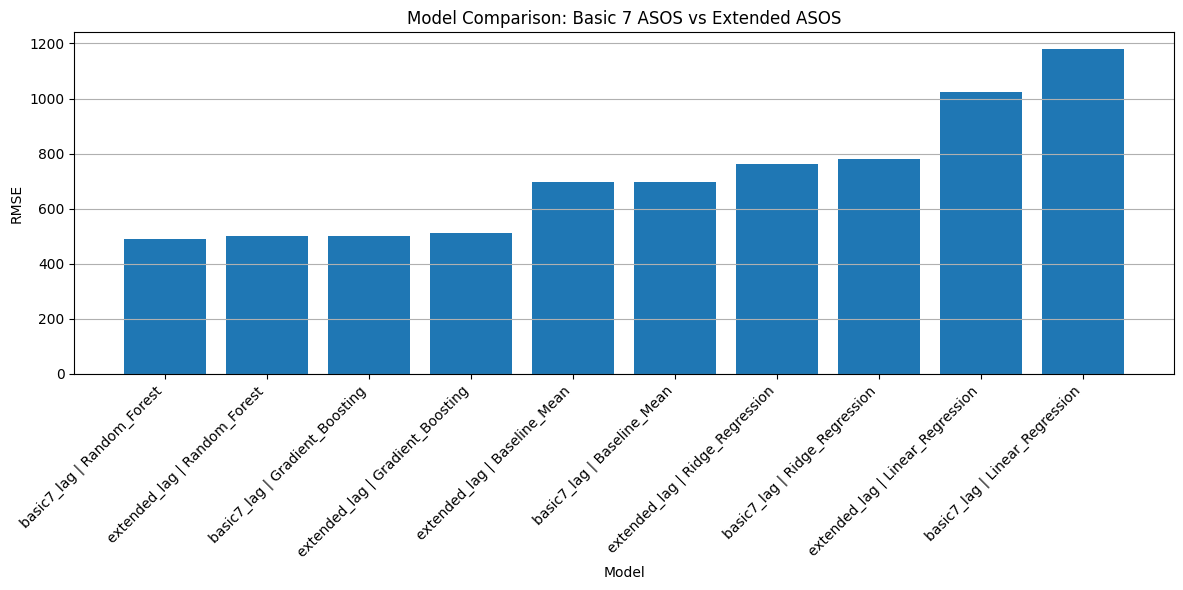

In [13]:
# =========================================================
# 12. RMSE 비교 그래프
# =========================================================

plt.figure(figsize=(12, 6))

labels = comparison_df["version"] + " | " + comparison_df["model"]

plt.bar(labels, comparison_df["RMSE"])
plt.title("Model Comparison: Basic 7 ASOS vs Extended ASOS")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.tight_layout()

plt.show()

최종 최고 모델
version       basic7_lag
model      Random_Forest
MAE           338.217832
RMSE          489.024653
R2               0.45299
Name: 0, dtype: object


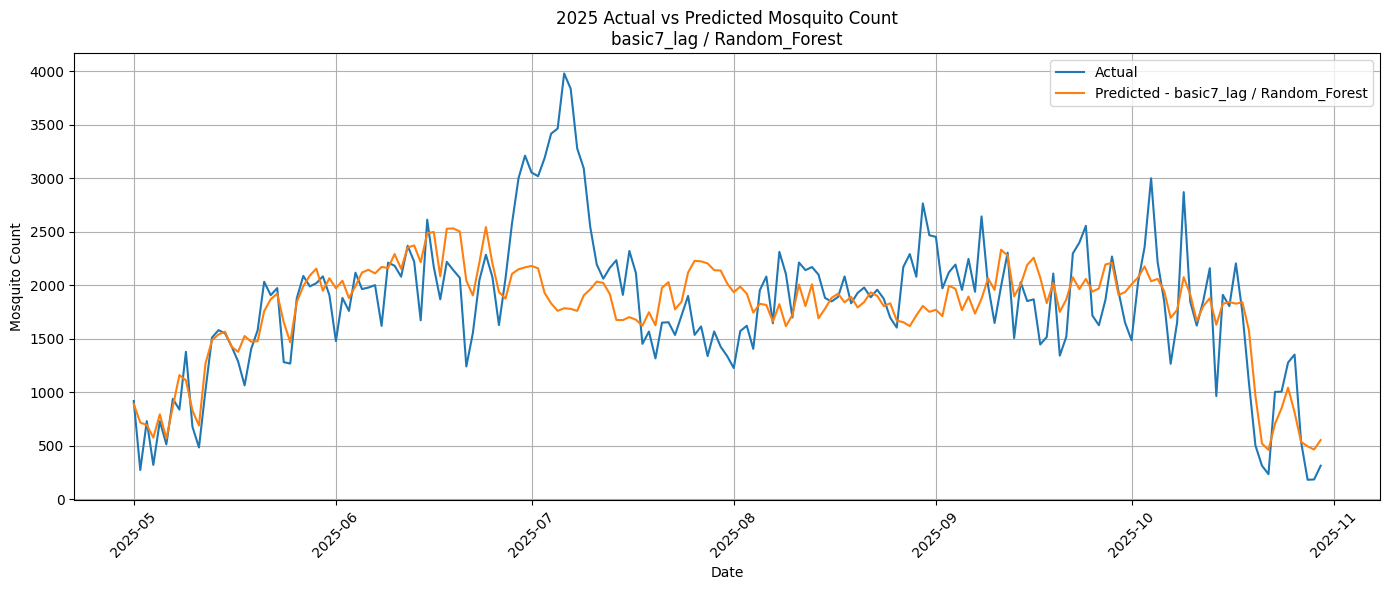

In [14]:
# =========================================================
# 13. 최종 최고 모델 실제값 vs 예측값
# =========================================================

best_row = comparison_df.iloc[0]
best_version = best_row["version"]
best_model_name = best_row["model"]

print("최종 최고 모델")
print(best_row)

if best_version == "basic7_lag":
    best_predictions = basic_result["predictions"]
else:
    best_predictions = extended_result["predictions"]

plt.figure(figsize=(14, 6))

plt.plot(
    pd.to_datetime(best_predictions["date"]),
    best_predictions["actual"],
    label="Actual"
)

plt.plot(
    pd.to_datetime(best_predictions["date"]),
    best_predictions[best_model_name],
    label=f"Predicted - {best_version} / {best_model_name}"
)

plt.title(f"2025 Actual vs Predicted Mosquito Count\n{best_version} / {best_model_name}")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

,feature,importance
17,soil_temp_5cm_mean,0.268179
0,year,0.198702
19,day_of_year,0.051684
98,soil_temp_5cm_mean_7d_mean,0.040542
94,soil_temp_5cm_mean_lag1,0.027064
16,ground_temp_min,0.020272
5,temp_min,0.019992
20,week_of_year,0.019497
38,temp_min_7d_mean,0.017665
74,solar_sum_lag1,0.017299


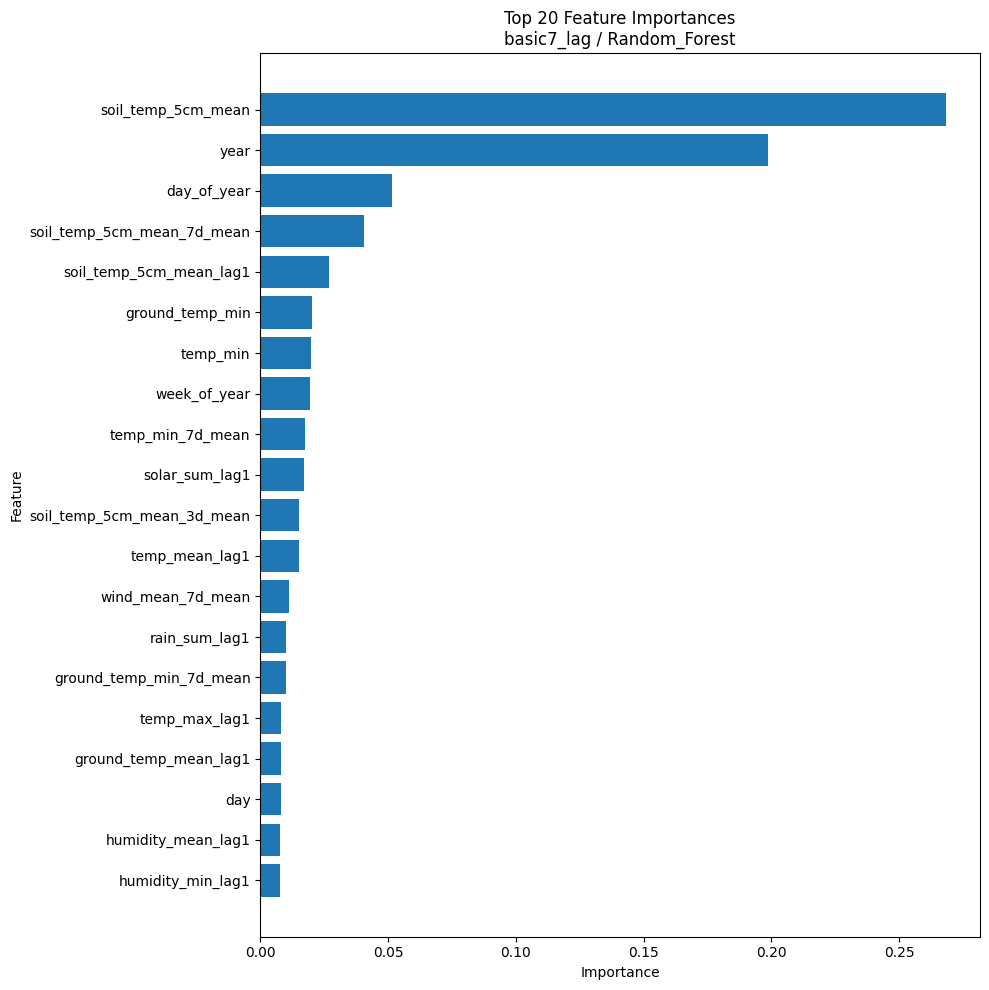

In [15]:
# =========================================================
# 14. 변수 중요도 확인
# =========================================================

if best_version == "basic7_lag":
    importance_df = basic_result["importance_df"]
else:
    importance_df = extended_result["importance_df"]

if importance_df is not None:
    display(importance_df.head(30))

    plt.figure(figsize=(10, 10))
    plt.barh(
        importance_df.head(20)["feature"][::-1],
        importance_df.head(20)["importance"][::-1]
    )
    plt.title(f"Top 20 Feature Importances\n{best_version} / {best_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()
else:
    print("최종 최고 모델은 변수 중요도를 제공하지 않습니다.")

정확도가 너무 낮게 나옴
문제점이 무엇이 있을까 생각해봤을 때
1. 기상변수만으로 모기포집량을 예측하기에는 어려움이 있다.
2. RandomForest는 극단적인 피크를 예측하는데 어려움이 있다.(예측값이 부드러워지기 때문)
3. 이전 모기 포집량 정보를 넣지 않으면 성능이 낮아질 수 있다.

따라서 나온 해결방안
###1. 이전 모기포집량 lag 변수 추가
###2. log 변환 적용
###3. 수치 예측 말고 위험 등급도 같이 예측

In [17]:
# =========================================================
# 1. 모기포집량 lag 변수 추가 함수
# =========================================================
def add_mosquito_lag_features(df):
    df = df.copy()
    df = df.sort_values(["year", "date"]).reset_index(drop=True)

    df["mosquito_count_lag1"] = df.groupby("year")["mosquito_count"].shift(1)
    df["mosquito_count_lag3"] = df.groupby("year")["mosquito_count"].shift(3)
    df["mosquito_count_lag7"] = df.groupby("year")["mosquito_count"].shift(7)

    df["mosquito_count_3d_mean"] = (
        df.groupby("year")["mosquito_count"]
          .transform(lambda x: x.shift(1).rolling(window=3, min_periods=1).mean())
    )

    df["mosquito_count_7d_mean"] = (
        df.groupby("year")["mosquito_count"]
          .transform(lambda x: x.shift(1).rolling(window=7, min_periods=1).mean())
    )

    return df

In [18]:
# =========================================================
# 2. train/test 합친 뒤 lag 생성
# =========================================================
# 확장 모델 기준으로 진행
train_tmp = train_extended.copy()
test_tmp = test_extended.copy()

train_tmp["dataset"] = "train"
test_tmp["dataset"] = "test"

all_tmp = pd.concat([train_tmp, test_tmp], ignore_index=True)
all_tmp["date"] = pd.to_datetime(all_tmp["date"])
all_tmp = all_tmp.sort_values("date").reset_index(drop=True)

all_tmp = add_mosquito_lag_features(all_tmp)

train_mlag = all_tmp[all_tmp["dataset"] == "train"].copy()
test_mlag = all_tmp[all_tmp["dataset"] == "test"].copy()

print(train_mlag.shape)
print(test_mlag.shape)

(903, 159)
(183, 159)


In [19]:
# =========================================================
# 3. log 변환 모델링 함수
# =========================================================

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import numpy as np
import pandas as pd


def run_log_target_models(train_df, test_df, version_name):
    TARGET_COL = "mosquito_count"

    drop_cols = [
        "date",
        "dataset",
        "source_year",
        "trap_total",
        "other_count",
        TARGET_COL
    ]

    drop_cols = [col for col in drop_cols if col in train_df.columns]

    feature_cols = [col for col in train_df.columns if col not in drop_cols]

    X_train = train_df[feature_cols].copy()
    y_train = train_df[TARGET_COL].copy()

    X_test = test_df[feature_cols].copy()
    y_test = test_df[TARGET_COL].copy()

    categorical_cols = [
        col for col in feature_cols
        if X_train[col].dtype == "object"
    ]

    numeric_cols = [
        col for col in feature_cols
        if col not in categorical_cols
    ]

    try:
        onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

    numeric_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", onehot)
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_cols),
            ("cat", categorical_pipeline, categorical_cols)
        ],
        remainder="drop"
    )

    X_train_processed = preprocessor.fit_transform(X_train)
    X_test_processed = preprocessor.transform(X_test)

    # log target
    y_train_log = np.log1p(y_train)

    models = {
        "Baseline_Mean_Log": DummyRegressor(strategy="mean"),
        "Ridge_Log": Ridge(alpha=1.0),
        "Random_Forest_Log": RandomForestRegressor(
            n_estimators=500,
            random_state=42,
            n_jobs=-1,
            max_depth=None,
            min_samples_leaf=2
        ),
        "Gradient_Boosting_Log": GradientBoostingRegressor(
            random_state=42,
            n_estimators=500,
            learning_rate=0.03,
            max_depth=3
        )
    }

    results = []

    predictions = pd.DataFrame({
        "date": test_df["date"],
        "actual": y_test
    })

    trained_models = {}

    for model_name, model in models.items():
        print(f"\n[{version_name}] {model_name} 학습 중")

        model.fit(X_train_processed, y_train_log)

        y_pred_log = model.predict(X_test_processed)

        # log 값을 원래 모기 수 단위로 복원
        y_pred = np.expm1(y_pred_log)

        # 음수 예측 방지
        y_pred = np.clip(y_pred, 0, None)

        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        results.append({
            "version": version_name,
            "model": model_name,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2
        })

        predictions[model_name] = y_pred
        trained_models[model_name] = model

        print("MAE:", round(mae, 3))
        print("RMSE:", round(rmse, 3))
        print("R2:", round(r2, 3))

    results_df = pd.DataFrame(results).sort_values("RMSE")

    return results_df, predictions, trained_models

In [20]:
# =========================================================
# 4. 개선 모델 실행
# =========================================================
results_mlag_log, predictions_mlag_log, trained_mlag_log = run_log_target_models(
    train_mlag,
    test_mlag,
    version_name="extended_lag_mosquito_lag_log"
)

display(results_mlag_log)


[extended_lag_mosquito_lag_log] Baseline_Mean_Log 학습 중
MAE: 486.741
RMSE: 661.562
R2: -0.001

[extended_lag_mosquito_lag_log] Ridge_Log 학습 중
MAE: 425.651
RMSE: 591.889
R2: 0.199

[extended_lag_mosquito_lag_log] Random_Forest_Log 학습 중
MAE: 274.633
RMSE: 362.809
R2: 0.699

[extended_lag_mosquito_lag_log] Gradient_Boosting_Log 학습 중
MAE: 265.931
RMSE: 347.771
R2: 0.723


,version,model,MAE,RMSE,R2
3,extended_lag_mosquito_lag_log,Gradient_Boosting_Log,265.930579,347.771192,0.723356
2,extended_lag_mosquito_lag_log,Random_Forest_Log,274.633278,362.809451,0.698914
1,extended_lag_mosquito_lag_log,Ridge_Log,425.650898,591.889282,0.198664
0,extended_lag_mosquito_lag_log,Baseline_Mean_Log,486.741453,661.561610,-0.001093


In [21]:
# =========================================================
# 5. 기존 결과와 비교
# =========================================================
# 기존 비교 결과가 있다면 함께 비교
compare_new = results_mlag_log.copy()

try:
    old_compare = pd.read_csv(
        OUTPUT_DIR / "model_metrics_comparison_basic7_vs_extended.csv",
        encoding="utf-8-sig"
    )
    final_compare = pd.concat([old_compare, compare_new], ignore_index=True)
except:
    final_compare = compare_new

final_compare = final_compare.sort_values("RMSE")

display(final_compare)

final_compare.to_csv(
    OUTPUT_DIR / "model_metrics_final_comparison.csv",
    index=False,
    encoding="utf-8-sig"
)

,version,model,MAE,RMSE,R2
10,extended_lag_mosquito_lag_log,Gradient_Boosting_Log,265.930579,347.771192,0.723356
11,extended_lag_mosquito_lag_log,Random_Forest_Log,274.633278,362.809451,0.698914
0,basic7_lag,Random_Forest,338.217832,489.024653,0.452990
1,extended_lag,Random_Forest,356.044444,499.671447,0.428912
2,basic7_lag,Gradient_Boosting,344.551963,500.581552,0.426830
3,extended_lag,Gradient_Boosting,370.212638,512.190388,0.399937
12,extended_lag_mosquito_lag_log,Ridge_Log,425.650898,591.889282,0.198664
13,extended_lag_mosquito_lag_log,Baseline_Mean_Log,486.741453,661.561610,-0.001093
5,basic7_lag,Baseline_Mean,504.204461,697.982331,-0.114352
4,extended_lag,Baseline_Mean,504.204461,697.982331,-0.114352


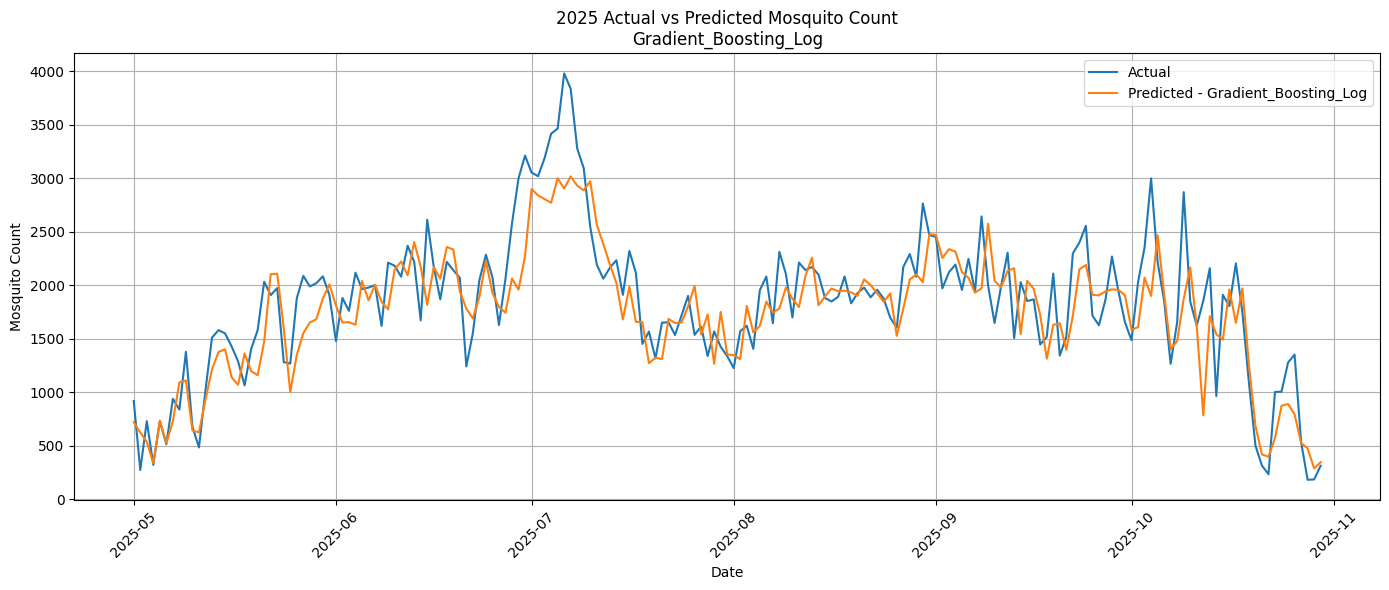

In [22]:
# =========================================================
# 6. 개선 모델 그래프
# =========================================================
best_row = results_mlag_log.iloc[0]
best_model_name = best_row["model"]

plt.figure(figsize=(14, 6))

plt.plot(
    pd.to_datetime(predictions_mlag_log["date"]),
    predictions_mlag_log["actual"],
    label="Actual"
)

plt.plot(
    pd.to_datetime(predictions_mlag_log["date"]),
    predictions_mlag_log[best_model_name],
    label=f"Predicted - {best_model_name}"
)

plt.title(f"2025 Actual vs Predicted Mosquito Count\n{best_model_name}")
plt.xlabel("Date")
plt.ylabel("Mosquito Count")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()